## Imports

In [1]:
import preprocesing_utils
import trainmodels_utils
from CityscapesDataModule import CityscapesDataModule

import torch
from torchvision import datasets
from torchvision.transforms import v2
from torch import nn

from ray import tune

from IPython.display import display, HTML
# Change the color of the RayTune Trial table to white, thanks to the dark mode of the IDE
display(HTML("""
<style>
.tuneStatus, .tuneStatus table, .tuneStatus h3, .tuneStatus div {
    color: #e0e0e0 !important; 
}
/* Optional: headers color */
.tuneStatus th {
    color: #b0b0b0 !important;
}
</style>
"""))

%load_ext tensorboard
%tensorboard --logdir ~/ray_results

In [2]:
print(f"PyTorch versión: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Versión de CUDA: {torch.version.cuda}")
    print(f"Versión de cuDNN: {torch.backends.cudnn.version()}")
    print(f"Dispositivo actual: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA no está disponible. PyTorch usará la CPU.")

PyTorch versión: 2.9.1+cu128
CUDA disponible: True
Versión de CUDA: 12.8
Versión de cuDNN: 91002
Dispositivo actual: NVIDIA GeForce RTX 3080 Ti


## Calculate Mean and Std of the Dataset

In [2]:
# Create the transforms
transform_mean_std = v2.Compose([
    # Convert to Image (torch.tensor)
    v2.ToImage(), 
    # Scale to [0, 1] and convert to torch.float32
    v2.ToDtype(torch.float32, scale=True)
])

transform_target = v2.Compose([
    # Convert to Image (torch.tensor)
    v2.ToImage()
])

In [3]:
# Load the data
train_data = datasets.Cityscapes(root='./Cityscapes_data', split='train', mode='fine', target_type=['semantic'], 
                                 transform=transform_mean_std, target_transform=transform_target)
val_data = datasets.Cityscapes(root='./Cityscapes_data', split='val', mode='fine', target_type=['semantic', 'instance'])
test_data = datasets.Cityscapes(root='./Cityscapes_data', split='test', mode='fine', target_type=['semantic', 'instance'])

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

Train size: 2975
Validation size: 500
Test size: 1525


In [3]:
# Create the train dataloader to calculate the mean and std

"""
mean, std = preprocesing_utils.calculate_mean_std(train_data)
print("\nMean across channel:", mean)
print("Std across channel:", std)
"""
# Save the mean and std
mean = torch.tensor([0.2869, 0.3251, 0.2839])
std = torch.tensor([0.1870, 0.1902, 0.1872])

## Calculate Each Class Weight

In [3]:
cityscapes = CityscapesDataModule(
    data_dir='./Cityscapes_data',
    batch_size=64,
    num_workers=4,
    mean=mean,
    std=std,
    crop_size=(512,1024)
)

cityscapes.setup()
train_dataloader = cityscapes.train_dataloader()

# Methods to calcule the weights 'inverse', 'median', or 'enet'
class_weights = preprocesing_utils.calculate_class_weights(train_dataloader, num_classes=19, 
                                                            method='enet', ignore_index=255)                                                           
print("Class weights len: ", class_weights.shape)
clases_cityscapes = cityscapes.train_data.classes
for class_cityscapes in clases_cityscapes:
    if class_cityscapes.train_id != 255 and class_cityscapes.train_id != -1:
        print(f"For {class_cityscapes.train_id} weight: {class_weights[class_cityscapes.train_id]:.3}")

/home/angel/anaconda3/envs/Pytorch_gpu/lib/python3.12/site-packages/albumentations/core/validation.py:133: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Calculating class weights (enet): 100%|██████████| 46/46 [00:47<00:00,  1.03s/it]

Class weights len:  torch.Size([19])
For 0 weight: 0.0888
For 1 weight: 0.438
For 2 weight: 0.191
For 3 weight: 1.23
For 4 weight: 1.14
For 5 weight: 1.02
For 6 weight: 1.55
For 7 weight: 1.34
For 8 weight: 0.235
For 9 weight: 1.05
For 10 weight: 0.815
For 11 weight: 0.872
For 12 weight: 1.51
For 13 weight: 0.305
For 14 weight: 1.43
For 15 weight: 1.45
For 16 weight: 1.48
For 17 weight: 1.58
For 18 weight: 1.29


## Load Cityscapes DataModule

/home/angel/anaconda3/envs/Pytorch_gpu/lib/python3.12/site-packages/albumentations/core/validation.py:133: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Batch images cityscapes:  torch.Size([8, 3, 512, 1024])
Batch masks classes prediction cityscapes:  torch.Size([8, 512, 1024])


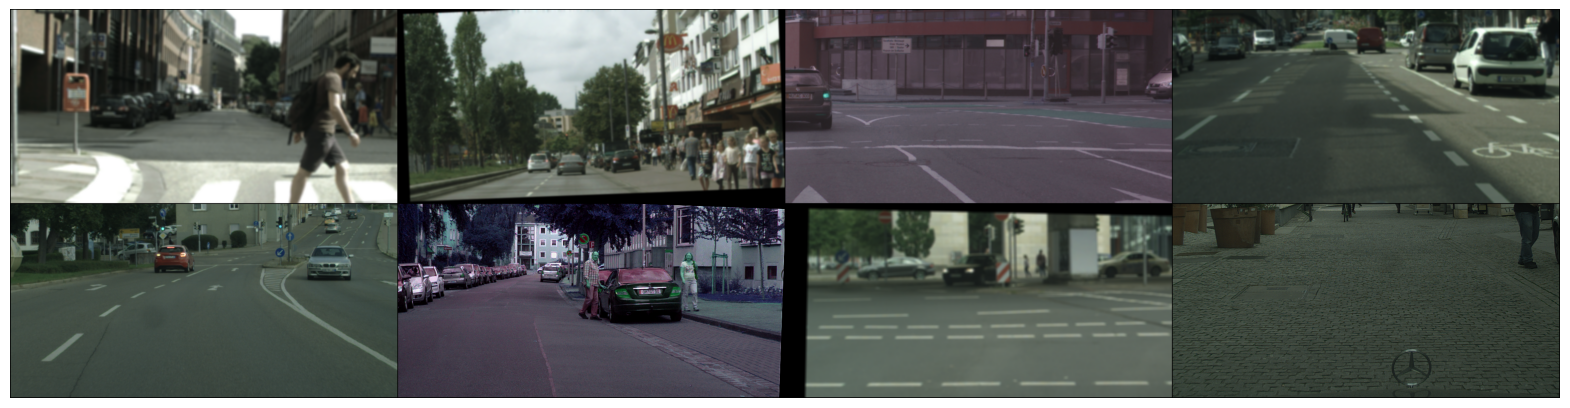

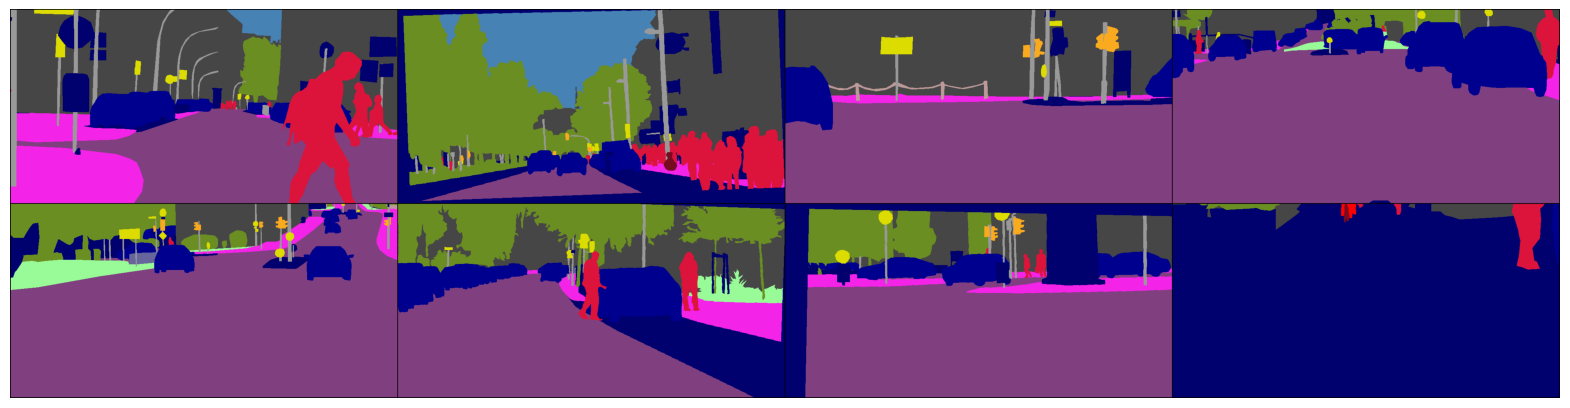

ID    | TrainID  | Nombre               | Categoría       | Color (RGB)
---------------------------------------------------------------------------
0     | 255      | unlabeled            | void            | (0, 0, 0)
1     | 255      | ego vehicle          | void            | (0, 0, 0)
2     | 255      | rectification border | void            | (0, 0, 0)
3     | 255      | out of roi           | void            | (0, 0, 0)
4     | 255      | static               | void            | (0, 0, 0)
5     | 255      | dynamic              | void            | (111, 74, 0)
6     | 255      | ground               | void            | (81, 0, 81)
7     | 0        | road                 | flat            | (128, 64, 128)
8     | 1        | sidewalk             | flat            | (244, 35, 232)
9     | 255      | parking              | flat            | (250, 170, 160)
10    | 255      | rail track           | flat            | (230, 150, 140)
11    | 2        | building             | construction 

In [8]:
from torchvision.utils import make_grid

num_images_display = 8
cityscapes = CityscapesDataModule(
    data_dir='./Cityscapes_data',
    batch_size=num_images_display,
    num_workers=2,
    mean=mean,
    std=std,
    crop_size=(512,1024)
)

cityscapes.setup()
train_dataloader = cityscapes.train_dataloader()

images_batch, target_masks = next(iter(train_dataloader))
print("Batch images cityscapes: ", images_batch.shape)
print("Batch masks classes prediction cityscapes: ", target_masks.shape)

images_batch_denormalized = preprocesing_utils.denormalize_image(images_batch, mean, std)
masks_colored = preprocesing_utils.colored_target_mask(target_masks, cityscapes.train_data.classes)

grid_images = make_grid(images_batch_denormalized, nrow=num_images_display//2, padding=2)
grid_masks = make_grid(masks_colored, nrow=num_images_display//2, padding=2)

preprocesing_utils.display_grid(grid_images)
preprocesing_utils.display_grid(grid_masks)

clases_cityscapes = cityscapes.train_data.classes

# Imprimimos una cabecera bonita
print(f"{'ID':<5} | {'TrainID':<8} | {'Nombre':<20} | {'Categoría':<15} | {'Color (RGB)'}")
print("-" * 75)

# Iteramos sobre cada objeto de clase y sacamos sus atributos
for c in clases_cityscapes:
    print(f"{c.id:<5} | {c.train_id:<8} | {c.name:<20} | {c.category:<15} | {c.color}")


In [9]:
# Print unique values of the batch target masks
valores_unicos = torch.unique(target_masks)
print("Unique values in the target masks:", valores_unicos.tolist())

Unique values in the target masks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 18, 255]


## Try Pytorch Profiler

In [4]:
profiler_hyperparameters_search_space = {
    "learning_rate": 1e-3,
    "batch_size": 10,
    "grad_accum": 1,
    "filters": [64, 128, 256, 512, 1024],
    "dropout_prob": 0.2,
    "weight_decay": 1e-2,
    "crop_size": (512, 512)
}
profiler_loss_fn = nn.CrossEntropyLoss(ignore_index=255)

In [5]:
profiler = trainmodels_utils.model_profiler(
    hyperparameters_space=profiler_hyperparameters_search_space,
    loss=profiler_loss_fn,
    mean_dataset=mean,
    std_dataset=std
)

Seed set to 1234
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/angel/anaconda3/envs/Pytorch_gpu/lib/python3.12/site-packages/albumentations/core/validation.py:133: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/angel/anaconda3/envs/Pytorch_gpu/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name            | Type                   | Params | Mode  |

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.50 GiB. GPU 0 has a total capacity of 11.62 GiB of which 1.95 GiB is free. Including non-PyTorch memory, this process has 9.17 GiB memory in use. Of the allocated memory 7.46 GiB is allocated by PyTorch, and 1.42 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [9]:
print(profiler.function_events.key_averages().table(sort_by="cpu_time_total", row_limit=10))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*        18.36%        2.175s        39.97%        4.734s     118.349ms       0.000us         0.00%     387.248ms       9.681ms           0 B         320 B           0 B     159.82 G

In [7]:
import pandas as pd

def display_profiler_results(profiler):
    
    event_info = []
    for event in profiler.function_events.key_averages():
        event_info.append({
            "Action": event.key,
            "Total Time (ms)": (event.cpu_time_total / 1000 + event.device_time_total / 1000),
            "Cpu Time (ms)": event.cpu_time_total / 1000,
            "Cuda Time (ms)": event.device_time_total / 1000,
            "Memory CPU (MB)": event.cpu_memory_usage / (1024 * 1024),
            "Memory Cuda (MB)": event.device_memory_usage / (1024 * 1024),
            "Count": event.count
        })

    profiler_df = pd.DataFrame(event_info)
    profiler_df = profiler_df.sort_values(by="Total Time (ms)", ascending=False)
    profiler_df = profiler_df.reset_index(drop=True)

    styler = profiler_df.head(30).style.hide(axis="index")
    styler.format({
        "Total Time (ms)": "{:.2f}",
        "Cpu Time (ms)": "{:.2f}",
        "Cuda Time (ms)": "{:.2f}",
        "Memory CPU (MB)": "{:.2f}",
        "Memory Cuda (MB)": "{:.2f}",
    }).set_properties(**{"text-align": "left"}, **{"white-space": "normal"}).set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])

    display(styler)

display_profiler_results(profiler)

Action,Total Time (ms),Cpu Time (ms),Cuda Time (ms),Memory CPU (MB),Memory Cuda (MB),Count
[pl][profile]run_training_batch,6650.43,4319.59,2330.84,0.00,0.02,40
[pl][profile][LightningModule]DriveSegmentationLightningModule.optimizer_step,6644.16,4313.32,2330.84,0.00,0.04,40
Optimizer.step#AdamW.step,6642.05,4311.21,2330.84,0.00,0.04,40
ProfilerStep*,4766.24,4474.71,291.54,0.00,0.00,40
[pl][profile][Strategy]SingleDeviceStrategy.training_step,4466.55,2075.57,2390.98,0.00,171950.06,40
Command Buffer Full,4274.44,3514.25,760.19,0.00,0.00,7851
[pl][module]torch._dynamo.eval_frame.OptimizedModule: model,3650.90,1700.78,1950.12,0.00,156750.02,40
[pl][module]model.DriveSegmentationModel.U_Net: model._orig_mod,3647.28,1697.16,1950.12,0.00,156750.02,40
cudaLaunchKernel,3295.08,2720.69,574.39,0.00,0.00,16320
autograd::engine::evaluate_function: ConvolutionBackward0,2691.70,941.46,1750.24,0.00,-21319.86,1160


## Model Hyperparameters

In [ ]:
mean = torch.tensor([0.2869, 0.3251, 0.2839])
std = torch.tensor([0.1870, 0.1902, 0.1872])

hyperparameters_search_space = {
    "learning_rate": 1e-2,
    "batch_size": tune.choice([32]),
    "grad_accum": 1,
    "max_epochs": 25,
    "filters": [64, 128, 256, 512, 1024],
    "use_checkpointing": False,
    "dropout_prob": 0.2,
    "crop_size": (256, 512),
    "weight_decay": 1e-2
}

# Inverse classes weights
class_weights_inverse = torch.tensor([0.0139, 0.0964, 0.0311, 0.8548, 0.5863, 0.4107, 3.1920, 1.0468, 0.0411,0.4709, 0.2476, 0.2987, 2.1577, 0.0601, 1.5577, 1.6191, 1.7126, 3.6827, 0.9200])
# Median classes weights
class_weights_median = torch.tensor([0.0131, 0.0939, 0.0307, 0.7106, 0.5522, 0.4035, 3.0099, 1.0337, 0.0409, 0.4194, 0.2477, 0.2895, 2.2852, 0.0565, 1.7237, 1.7530, 1.6304, 3.8030, 0.9028])
# enet classes weights
class_weights_enet = torch.tensor([0.0888, 0.4384, 0.1912, 1.2253, 1.1356, 1.0176, 1.5467, 1.3445, 0.2354, 1.0530, 0.8155, 0.8719, 1.5051, 0.3052, 1.4291, 1.4510, 1.4800, 1.5778, 1.2878])

loss_fn = nn.CrossEntropyLoss(ignore_index=255)

## Hyperparameters Tuning with Ray Tune

In [4]:
print("Starting hyperparameter tuning with Ray Tune...")
results = trainmodels_utils.train_tune_hyperparameters(
    hyperparameters_space=hyperparameters_search_space,
    loss=loss_fn,
    mean_dataset=mean,
    std_dataset=std,
    num_trials=1,
    gpu_per_trial=1.0,
    cpu_per_trial=20
)

(train_model pid=20318) Seed set to 1234


(train_model pid=20318) ============================================================================================================================================================================================================================
(train_model pid=20318) Layer (type (var_name))                       Input Shape               Output Shape              Param #                   Trainable                 Kernel Shape              Mult-Adds                 Param %
(train_model pid=20318) ============================================================================================================================================================================================================================
(train_model pid=20318) U_Net (U_Net)                                 [32, 3, 256, 512]         [32, 19, 256, 512]        --                        True                      --                        --                             --
(train_model pid=20318) ├─ModuleList (enco

(train_model pid=20318) Using bfloat16 Automatic Mixed Precision (AMP)
(train_model pid=20318) GPU available: True (cuda), used: True
(train_model pid=20318) TPU available: False, using: 0 TPU cores
(train_model pid=20318) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(train_model pid=20318) 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
(train_model pid=20318) /home/angel/anaconda3/envs/Pytorch_gpu/lib/python3.12/site-packages/albumentations/core/validation.py:133: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
(train_model pid=20318)   original_init(self, **validated_kwargs)
(train_model pi

In [5]:
best_result = results.get_best_result(metric="val_loss", mode="min")

print(f"Best hyperparameters found : {best_result.config}")
print(f"Train Loss:  {best_result.metrics['train_loss']:.4f}")
print(f"Best Validation Loss: {best_result.metrics['val_loss']:.4f}. Best Validation Mean IoU: {best_result.metrics['val_iou']:.4f}")

Best hyperparameters found : {'learning_rate': 0.0001, 'batch_size': 32, 'grad_accum': 1, 'max_epochs': 25, 'filters': [32, 64, 128, 256, 512], 'use_checkpointing': [True, False, False, False, False], 'dropout_prob': 0.2, 'crop_size': (256, 512), 'weight_decay': 0.01}
Train Loss:  1.1360
Best Validation Loss: 1.0080. Best Validation Mean IoU: 0.1361
